In [1]:
# --- Step 1: Library Import ---
# use pandas for data manipulation and numpy for handling missing values (NaN)
import pandas as pd
import numpy as np

# --- Step 2: Create Synthetic Raw Data ---
# Simulating a real-world scenario where sensors might fail (resulting in NaNs)
raw_data = {
    "timestamp": [0, 1, 2, 3, 4, 5, 6],
    "pressure_bar": [101.3, 102.5, np.nan, 103.1, 350.0, np.nan, 101.8],
    "temperature_c": [22.1, 22.4, 23.0, np.nan, 45.0, 22.8, 22.5]
}

# Initialize the DataFrame
df_raw = pd.DataFrame(raw_data)

# Preview the raw data with missing values
print("Raw Data Preview:")
print(df_raw)

Raw Data Preview:
   timestamp  pressure_bar  temperature_c
0          0         101.3           22.1
1          1         102.5           22.4
2          2           NaN           23.0
3          3         103.1            NaN
4          4         350.0           45.0
5          5           NaN           22.8
6          6         101.8           22.5


In [2]:
# --- Step 3: Check for missing values (NaN) ---
# .isna() identifies null values, .sum() counts them per column
missing_values_count = df_raw.isna().sum()

print("--- Data Integrity Report ---")
print("Number of missing values in each column:")
print(missing_values_count)

# Optional: Calculate the percentage of missing data
total_rows = len(df_raw)
missing_percentage = (missing_values_count / total_rows) * 100
print("\nPercentage of missing data (%):")
print(missing_percentage)

--- Data Integrity Report ---
Number of missing values in each column:
timestamp        0
pressure_bar     2
temperature_c    1
dtype: int64

Percentage of missing data (%):
timestamp         0.000000
pressure_bar     28.571429
temperature_c    14.285714
dtype: float64


In [3]:
# --- Step 4: Data Imputation (Filling the Gaps) ---

# 1. Best Practice: Create a copy of the dataframe
# This ensures don't accidentally mess up the raw data
df_cleaned = df_raw.copy()

# 2. Calculate the average (mean) for each sensor column
# Note: Pandas .mean() automatically ignores NaN values
avg_pressure = df_cleaned["pressure_bar"].mean()
avg_temp = df_cleaned["temperature_c"].mean()

print(f"Calculated Mean Pressure: {avg_pressure:.2f} bar")
print(f"Calculated Mean Temperature: {avg_temp:.2f} C")

# 3. Fill the NaNs with the calculated mean values
# The .fillna() method targets only the 'NaN' cells
df_cleaned["pressure_bar"] = df_cleaned["pressure_bar"].fillna(avg_pressure)
df_cleaned["temperature_c"] = df_cleaned["temperature_c"].fillna(avg_temp)

# 4. Final Verification: Check if any NaNs remain
print("\n--- Verification After Cleaning ---")
print(df_cleaned.isna().sum())

# Display the final cleaned table
df_cleaned

Calculated Mean Pressure: 151.74 bar
Calculated Mean Temperature: 26.30 C

--- Verification After Cleaning ---
timestamp        0
pressure_bar     0
temperature_c    0
dtype: int64


,timestamp,pressure_bar,temperature_c
0,0,101.30,22.1
1,1,102.50,22.4
2,2,151.74,23.0
3,3,103.10,26.3
4,4,350.00,45.0
5,5,151.74,22.8
6,6,101.80,22.5


In [4]:
# --- Step 5: Save the cleaned data ---
# We use index=False so we don't save the row numbers 0,1,2...
df_cleaned.to_csv("cleaned_sensor_data_v1.csv", index=False)

print("Final Step Complete: Cleaned data saved as 'cleaned_sensor_data_v1.csv'")

Final Step Complete: Cleaned data saved as 'cleaned_sensor_data_v1.csv'


In [1]:
# Import Libraries and Load Data ---
# matplotlib.pyplot is the standard library for data visualization in Python
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned dataset from our previous step
# Ensure the file 'cleaned_sensor_data_v1.csv' is in the same directory
df = pd.read_csv("cleaned_sensor_data_v1.csv")

# Basic Plotting (Pressure Trend) ---
# Initialize a figure with a professional aspect ratio (10x5 inches)
plt.figure(figsize=(10, 5))

# Plot the 'pressure_bar' against 'timestamp_s'
# This creates a basic line chart connecting the data points
plt.plot(df["timestamp_s"], df["pressure_bar"])

# Display the plot in the notebook
plt.show()

KeyError: 'timestamp_s'

<Figure size 1000x500 with 0 Axes>

In [2]:
# Check the exact column names in your dataframe
print(df.columns.tolist())


['timestamp', 'pressure_bar', 'temperature_c']


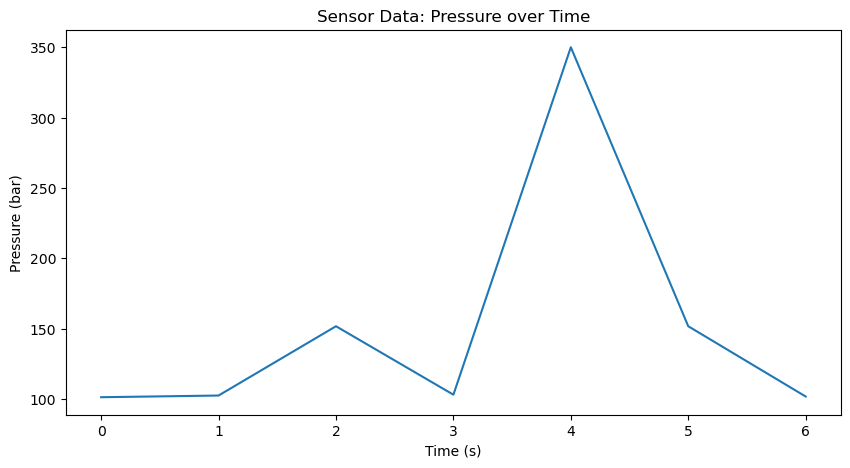

In [3]:
#  Visualization of Pressure Trend ---
# Setting the figure size for better visibility
plt.figure(figsize=(10, 5))

# Plotting 'pressure_bar' using 'timestamp' as the X-axis
# Note: Ensure the column names match the list we just printed
plt.plot(df["timestamp"], df["pressure_bar"])

# Adding labels and title (Crucial for any technical report)
plt.xlabel("Time (s)")
plt.ylabel("Pressure (bar)")
plt.title("Sensor Data: Pressure over Time")

# Display the plot
plt.show()

Success: Plot saved as 'sensor_analysis_plot.png'


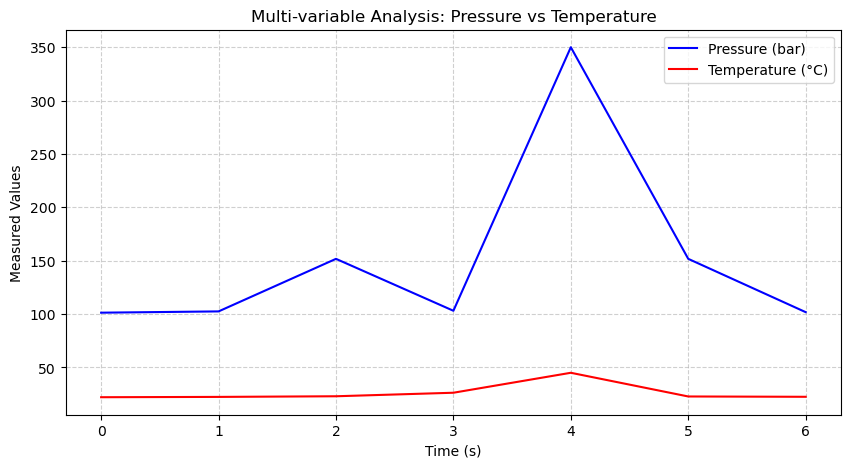

In [6]:
# Overlaying Temperature and Adding a Legend ---

#  Start with the same figure setup
plt.figure(figsize=(10, 5))

#  Plot Pressure (keep it blue)
# We add a 'label' here so the legend knows what to call this line
plt.plot(df["timestamp"], df["pressure_bar"], color="blue", label="Pressure (bar)")

#  Plot Temperature (let's use red for heat)
# This will be drawn on the SAME coordinate system
plt.plot(df["timestamp"], df["temperature_c"], color="red", label="Temperature (°C)")

#  Add the "Instruction Manual" (The Legend)
# This command automatically creates a box showing our labels
plt.legend()

# Adding the same professional labels as before
plt.xlabel("Time (s)")
plt.ylabel("Measured Values")
plt.title("Multi-variable Analysis: Pressure vs Temperature")
plt.grid(True, linestyle='--', alpha=0.6) # Add a subtle grid for better readability

plt.savefig("sensor_analysis_plot.png", dpi=300, bbox_inches='tight')

print("Success: Plot saved as 'sensor_analysis_plot.png'")

plt.show()

In [1]:
# --- Step 1 & 2: Statistical Analysis for Pressure ---

# Calculate basic statistics for Pressure
pressure_mean = df["pressure_bar"].mean()
pressure_std  = df["pressure_bar"].std()
pressure_max  = df["pressure_bar"].max()
pressure_min  = df["pressure_bar"].min()

# Display the results in a formatted way
print("--- Pressure Statistics ---")
print(f"Mean: {pressure_mean:.2f} bar")
print(f"Std Dev: {pressure_std:.2f}")
print(f"Max: {pressure_max:.2f} bar")
print(f"Min: {pressure_min:.2f} bar")

NameError: name 'df' is not defined

In [2]:
df = pd.read_csv("cleaned_sensor_data_v1.csv")

NameError: name 'pd' is not defined

In [3]:
import pandas as pd
import matplotlib.pyplot as plot

In [4]:
# Statistical Analysis for Pressure ---

# Calculate basic statistics for Pressure
pressure_mean = df["pressure_bar"].mean()
pressure_std  = df["pressure_bar"].std()
pressure_max  = df["pressure_bar"].max()
pressure_min  = df["pressure_bar"].min()

# Display the results in a formatted way
print("--- Pressure Statistics ---")
print(f"Mean: {pressure_mean:.2f} bar")
print(f"Std Dev: {pressure_std:.2f}")
print(f"Max: {pressure_max:.2f} bar")
print(f"Min: {pressure_min:.2f} bar")

NameError: name 'df' is not defined

In [5]:
df = pd.read_csv("cleaned_sensor_data_v1.csv")

In [6]:
pressure_mean = df["pressure_bar"].mean()
pressure_std  = df["pressure_bar"].std()
pressure_max  = df["pressure_bar"].max()
pressure_min  = df["pressure_bar"].min()

# Display the results in a formatted way
print("--- Pressure Statistics ---")
print(f"Mean: {pressure_mean:.2f} bar")
print(f"Std Dev: {pressure_std:.2f}")
print(f"Max: {pressure_max:.2f} bar")
print(f"Min: {pressure_min:.2f} bar")

--- Pressure Statistics ---
Mean: 151.74 bar
Std Dev: 90.49
Max: 350.00 bar
Min: 101.30 bar


In [7]:
print(f"Mean:{pressure_mean:.2f} bar")

Mean:151.74 bar


In [ ]:
### 📝 Data Analysis Summary
- **Pressure Anomaly:** The maximum pressure (350 bar) is significantly higher than the average, indicating a potential system spike.
- **Thermal Stability:** The temperature remains relatively stable with a low standard deviation, suggesting consistent cooling performance.